# **Projeto de Automação na Análise de Dados da Crise Global da Água Potável (Equipe 3)**

## Disciplina: Tópicos Especiais em Computação I

### Equipe:
- Vinicius Luis Silveira Barbosa
- Augusto Derik Onorato da Rocha
- Geilma Maria Melo Linhares
- Átila Fontenele Carneiro da Cunha
- Antonio Lucas Freire de Araújo
- William do Vale Mesquita
- Leandro Melo dos Santos

## Instalação das Bibliotecas Necessárias

In [ ]:
!pip install mlflow

## Importando Bibliotecas pra uso no projeto

In [ ]:
# Manipulação de Dados
import pandas as pd
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Pré Processamento
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Balanceamento
from imblearn.over_sampling import SMOTE

# MLFlow
import mlflow

# Configurações visuais
sns.set_style("whitegrid")

print("✅ Bibliotecas carregadas com sucesso!")


✅ Bibliotecas carregadas com sucesso!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving water_potability.csv to water_potability (2).csv


## Análise Exploratória dos Dados (EDA)

--- Primeiras Linhas ---


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0



--- Informações Gerais ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB

--- Estatísticas Descritivas ---


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


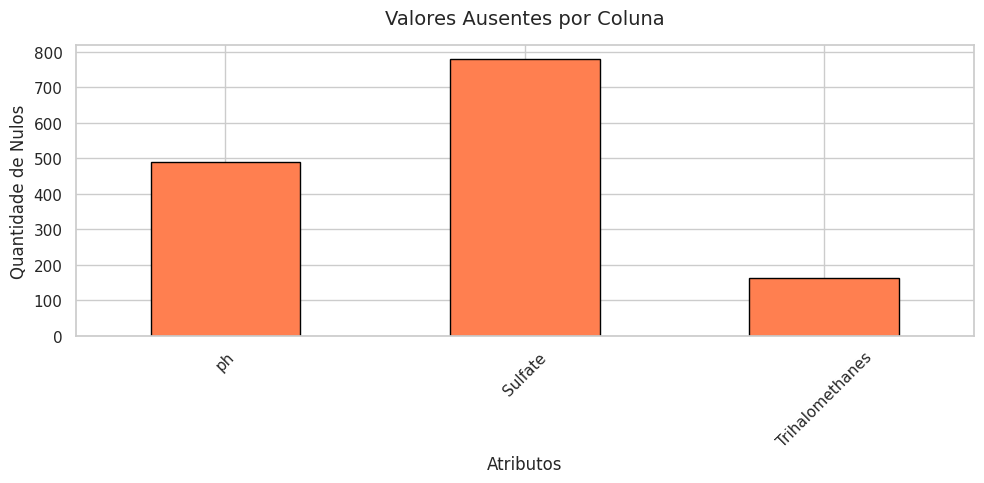

/tmp/ipykernel_1734/3748425456.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Potability', palette='viridis', ax=axes[0])


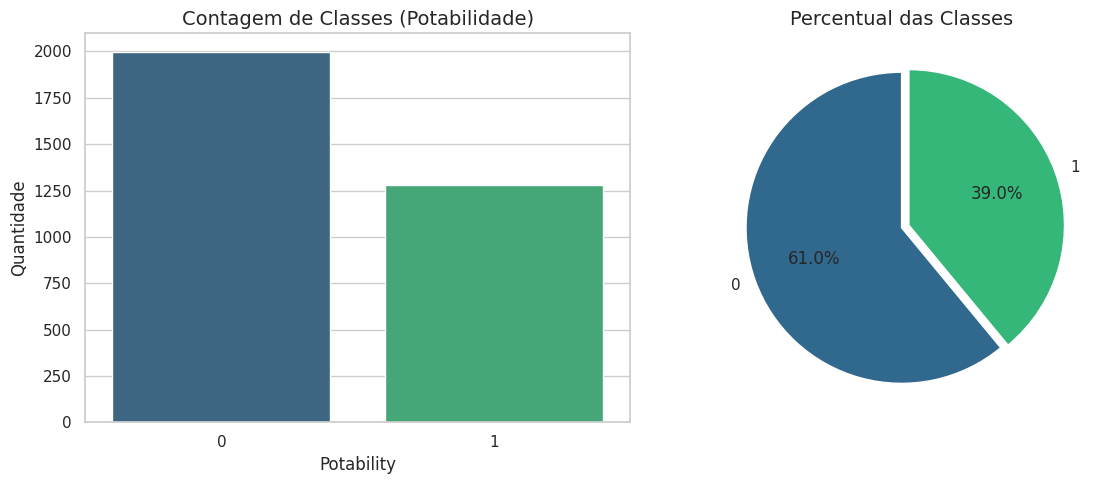

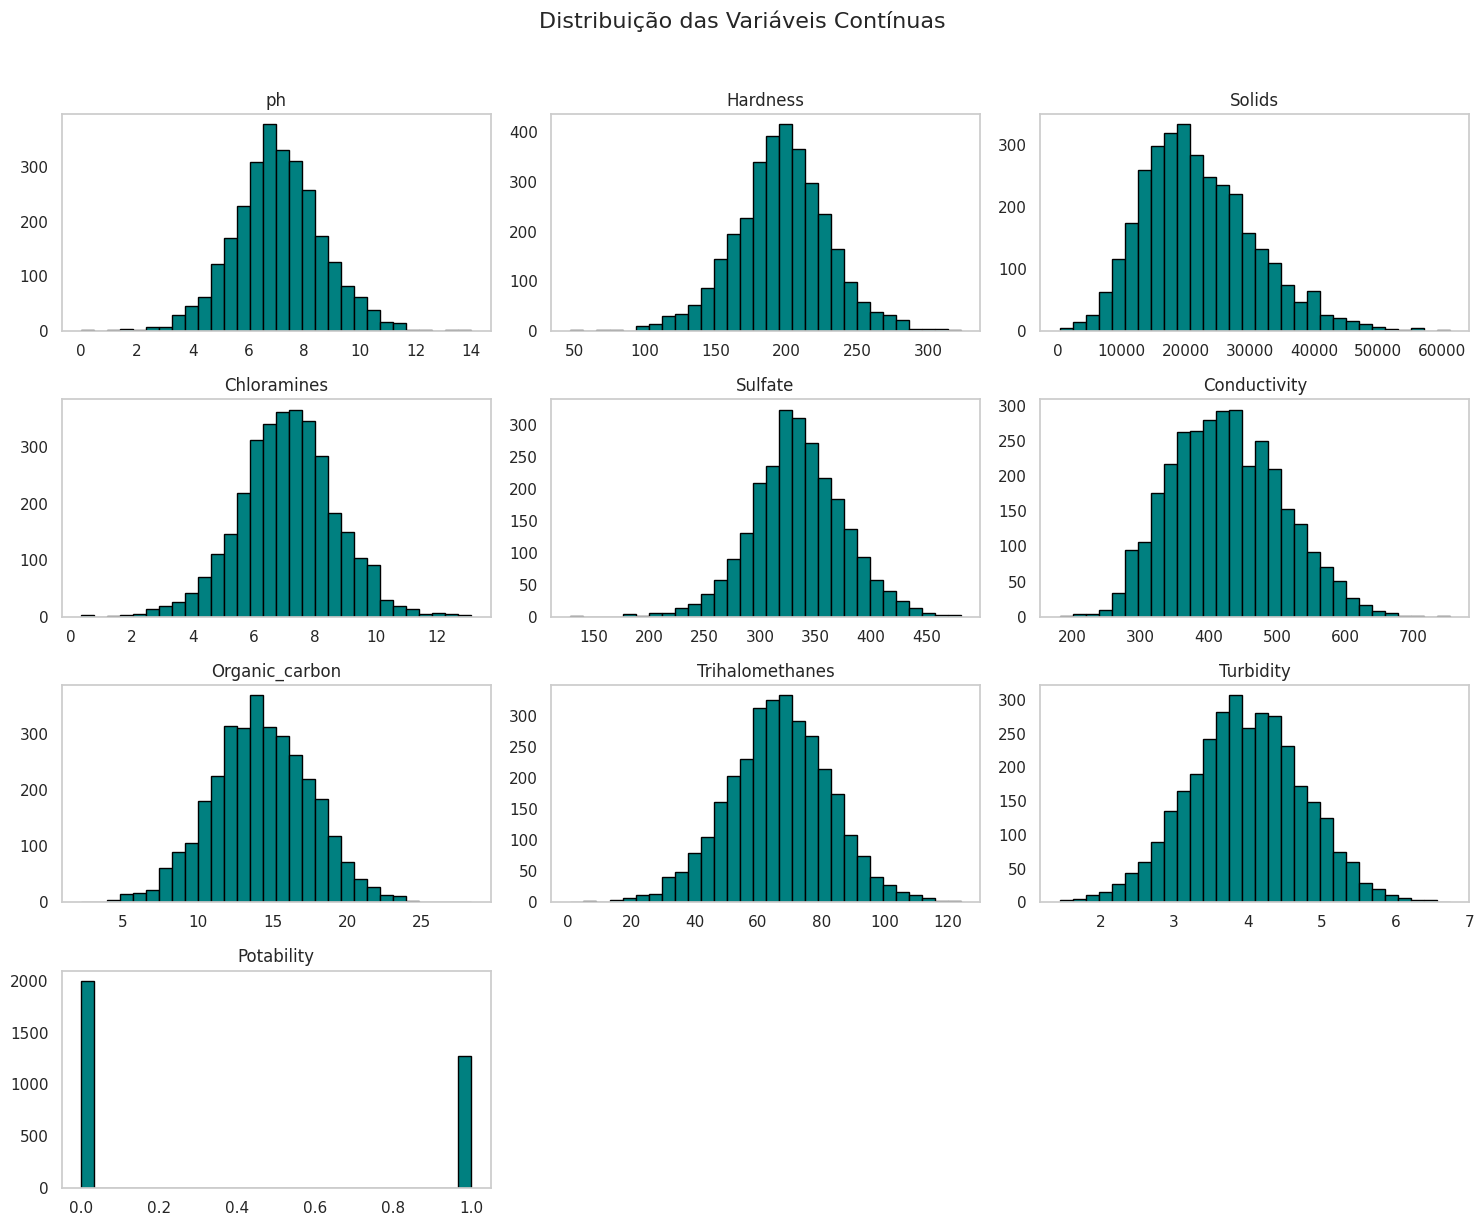

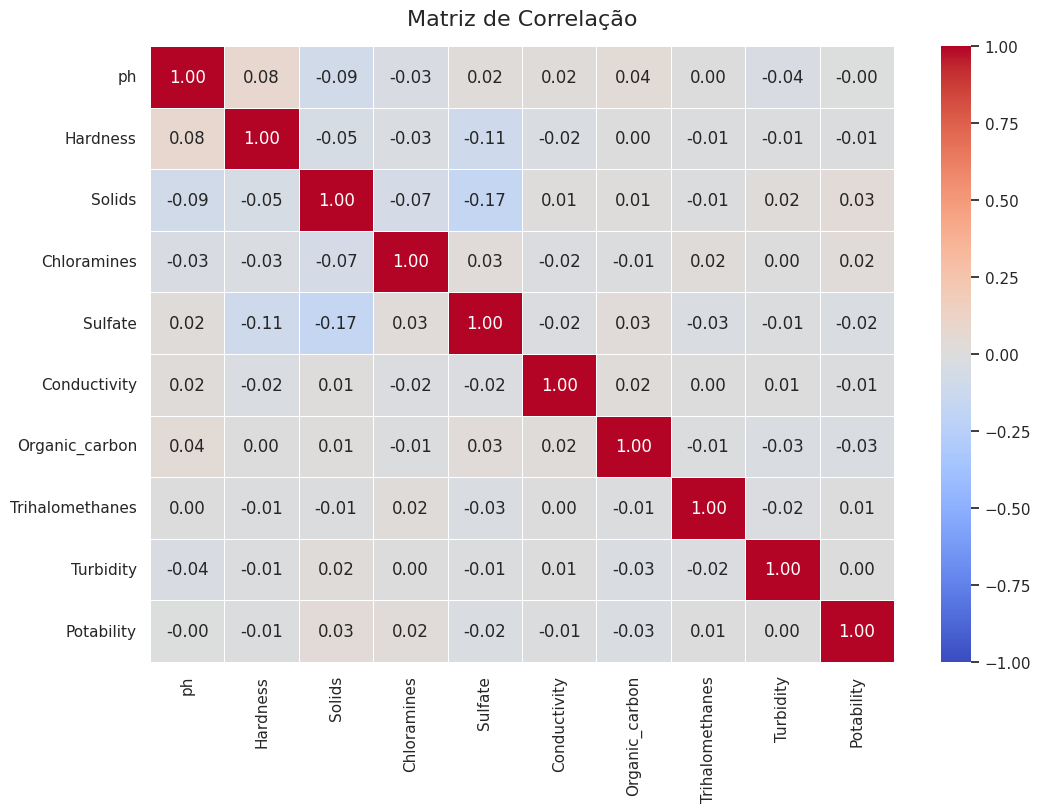

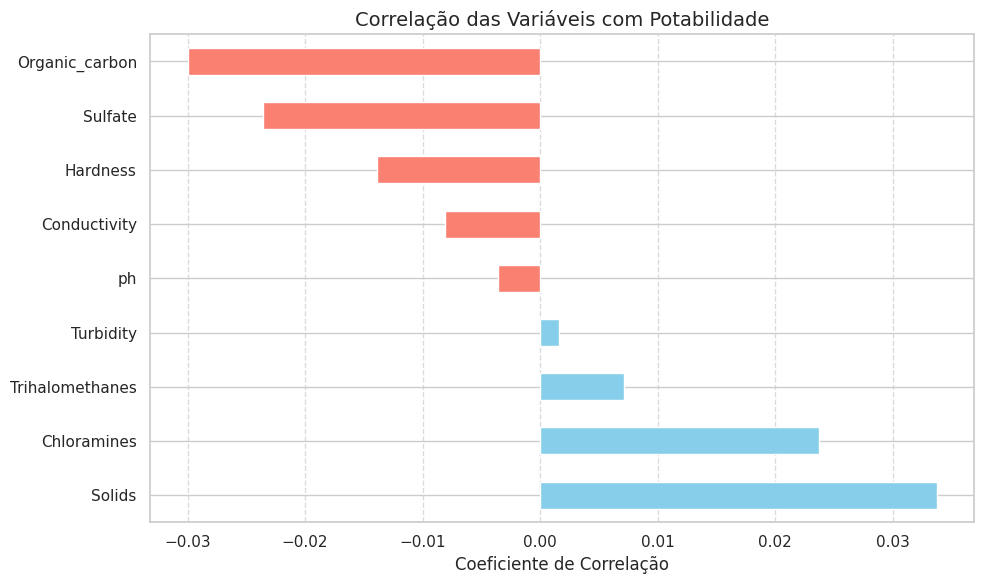

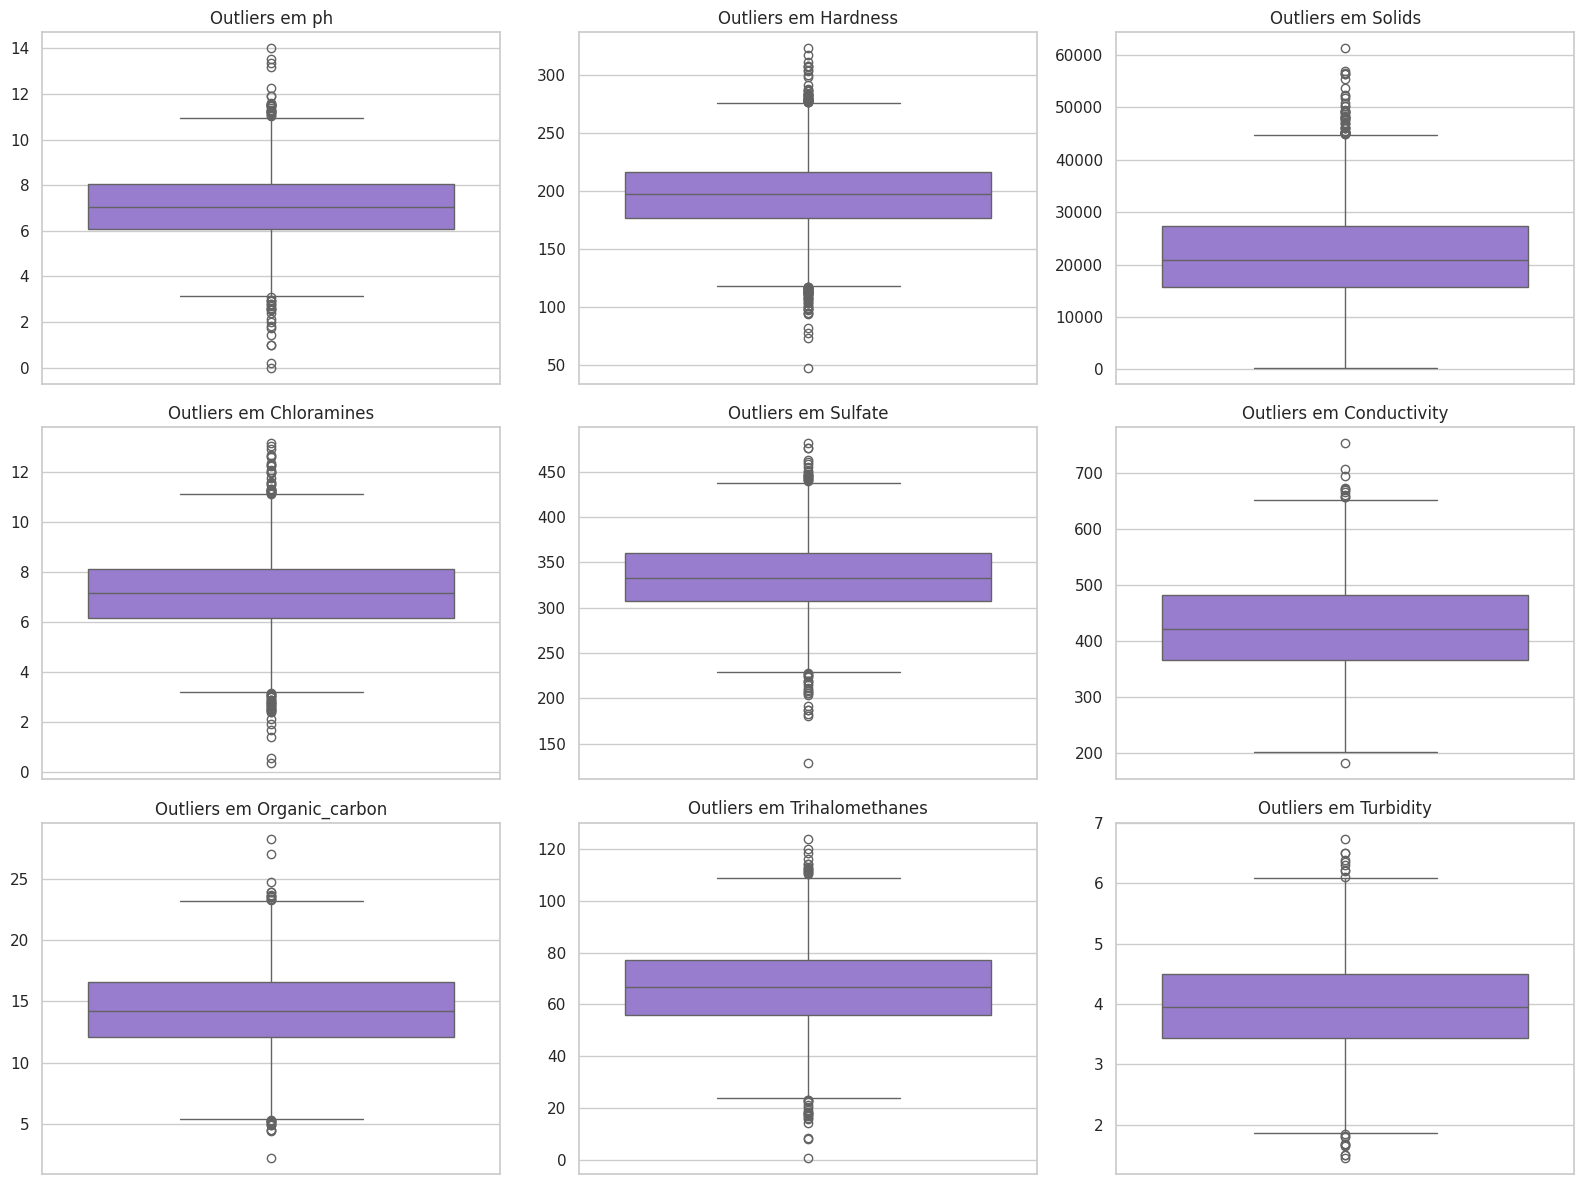

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurações Globais de Estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)

# Carregamento e informações básicas
df = pd.read_csv("water_potability.csv")

print("--- Primeiras Linhas ---")
display(df.head())

print("\n--- Informações Gerais ---")
df.info()

print("\n--- Estatísticas Descritivas ---")
display(df.describe())

# Gráfico 1: Valores Ausentes
missing = df.isnull().sum()

plt.figure(figsize=(10, 5))
missing[missing > 0].plot(kind='bar', color='coral', edgecolor='black')
plt.title('Valores Ausentes por Coluna', fontsize=14, pad=15)
plt.xlabel('Atributos', fontsize=12)
plt.ylabel('Quantidade de Nulos', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("="*100)

# Gráfico 2: Distribuição da Variável Alvo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de Barras
sns.countplot(data=df, x='Potability', palette='viridis', ax=axes[0])
axes[0].set_title('Contagem de Classes (Potabilidade)', fontsize=14)
axes[0].set_ylabel('Quantidade')

# Gráfico de Pizza
df['Potability'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', 2),
    ax=axes[1],
    startangle=90,
    explode=(0, 0.05)
)
axes[1].set_ylabel('')
axes[1].set_title('Percentual das Classes', fontsize=14)

plt.tight_layout()
plt.show()
print("="*100)

# Gráfico 3: Histograma (Distribuição das Variáveis)
df.hist(figsize=(15, 12), bins=30, color='teal', edgecolor='black', grid=False)
plt.suptitle('Distribuição das Variáveis Contínuas', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
print("="*100)

# Gráfico 4: Matriz de Correlação
plt.figure(figsize=(12, 8))
correlation = df.corr()
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Matriz de Correlação", fontsize=16, pad=15)
plt.show()
print("="*100)

# Gráfico 5: Correlação com o Alvo (Potability)
correlation_target = df.corr()['Potability'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
correlation_target.drop('Potability').plot(
    kind='barh',
    color=['skyblue' if c > 0 else 'salmon' for c in correlation_target.drop('Potability')]
)
plt.title('Correlação das Variáveis com Potabilidade', fontsize=14)
plt.xlabel('Coeficiente de Correlação')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("="*100)

# Gráfico 6: Boxplots para Outliers
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.drop('Potability')

plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='mediumpurple')
    plt.title(f'Outliers em {col}')
    plt.ylabel('')

plt.tight_layout()
plt.show()


### Principais descobertas

1. O dataset possui valores nulos.
2. O dataset apresenta desbalanceamento entre as classes.
3. Algumas variáveis possuem outliers.
4. Existem correlações fracas entre as variáveis e o alvo.
5. Será necessário realizar pré-processamento antes do treinamento.


## Tratamento dos Valores Nulos


In [ ]:
df.isnull().sum()

# Calculo da porcentagem de valores ausentes
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

# Como o dataset não é muito grande, perder linhas pode prejudicar o treinamento, melhor abordagem é:
# Substituir os nulos pela mediana


df_tratado = df.copy()

colunas_nulas = [
    'ph',
    'Sulfate',
    'Trihalomethanes'
]

for coluna in colunas_nulas:
    mediana = df_tratado[coluna].median()
    df_tratado[coluna].fillna(mediana, inplace=True)

df_tratado.isnull().sum()
df = df_tratado.copy()
df_tratado.describe()


/tmp/ipykernel_1734/1125164137.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_tratado[coluna].fillna(mediana, inplace=True)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,7.074194,196.369496,22014.092526,7.122277,333.608364,426.205111,14.284970,66.407478,3.966786,0.390110
std,1.470040,32.879761,8768.570828,1.583085,36.143851,80.824064,3.308162,15.769958,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.277673,176.850538,15666.690297,6.127421,317.094638,365.734414,12.065801,56.647656,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,7.870050,216.667456,27332.762127,8.114887,350.385756,481.792304,16.557652,76.666609,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


## Tratar Desbalanceamento

Antes do SMOTE:
Potability
0    1598
1    1022
Name: count, dtype: int64
Depois do SMOTE:
Potability
0    1598
1    1598
Name: count, dtype: int64


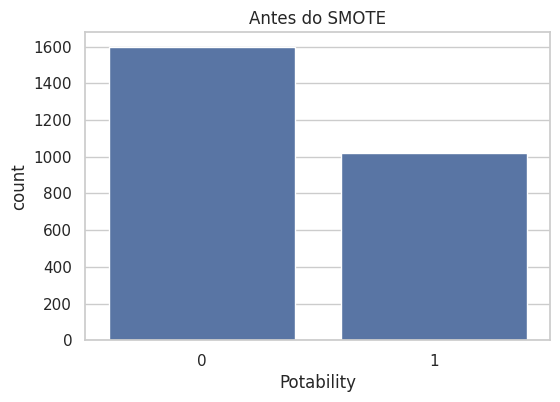

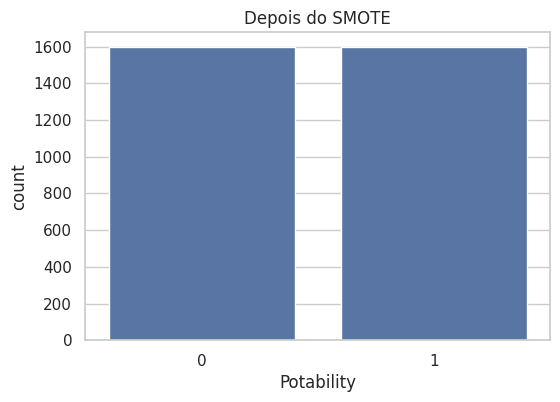

Treino original: (2620, 9)
Treino após SMOTE: (3196, 9)


In [ ]:
df['Potability'].value_counts()

# Separar variáveis e Alvo

X = df.drop('Potability', axis=1)
y = df['Potability']

# Dividir em Treino e Teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Antes do SMOTE:")
print(y_train.value_counts())

from imblearn.over_sampling import SMOTE
smote = SMOTE(
    random_state=42
)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Depois do SMOTE:")
print(y_train_smote.value_counts())


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Antes do SMOTE")
plt.show()


plt.figure(figsize=(6,4))
sns.countplot(x=y_train_smote)
plt.title("Depois do SMOTE")
plt.show()


print("Treino original:", X_train.shape)
print("Treino após SMOTE:", X_train_smote.shape)



#### O conjunto de dados apresentou desbalanceamento entre as classes de potabilidade. Para reduzir esse problema foi aplicada a técnica SMOTE (Synthetic Minority Over-sampling Technique), que gera amostras sintéticas da classe minoritária com base nos vizinhos mais próximos. Após a aplicação do método, as classes ficaram balanceadas, permitindo um treinamento mais adequado dos modelos de classificação.

## Treinamento de Regressão Logística

Accuracy : 0.5274
Precision: 0.4140
Recall   : 0.5078
F1-Score : 0.4561
[[216 184]
 [126 130]]


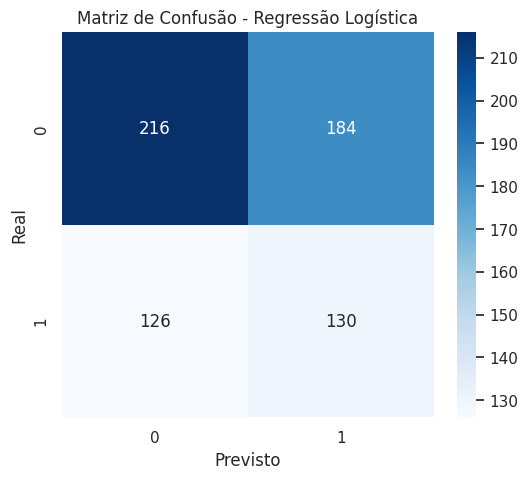

              precision    recall  f1-score   support

           0       0.63      0.54      0.58       400
           1       0.41      0.51      0.46       256

    accuracy                           0.53       656
   macro avg       0.52      0.52      0.52       656
weighted avg       0.55      0.53      0.53       656

AUC: 0.5279


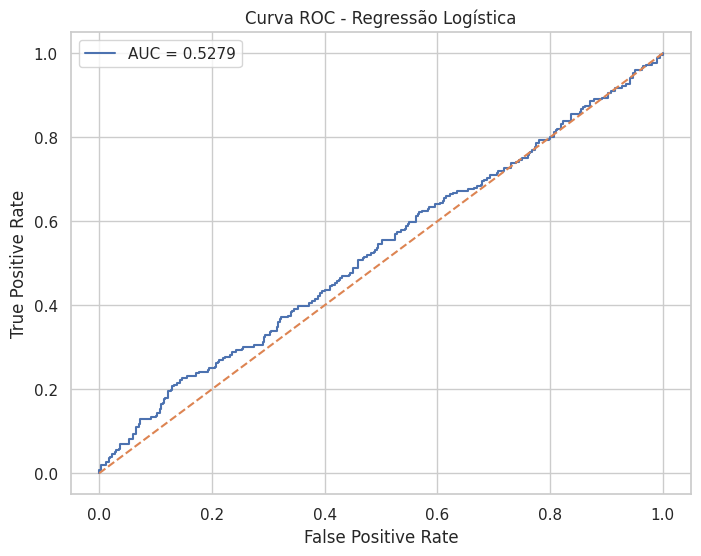

{'Modelo': 'Regressão Logística',
 'Accuracy': 0.5274390243902439,
 'Precision': 0.4140127388535032,
 'Recall': 0.5078125,
 'F1': 0.45614035087719296,
 'AUC': np.float64(0.527880859375)}

In [ ]:
# Padronizar os Dados

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Treinar a Regressão Logística
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(
    X_train_scaled,
    y_train_smote
)

# Fazer Previsões
y_pred_lr = lr_model.predict(X_test_scaled)

# Calcular Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# Matriz de Confusão
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)
print(cm)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

# Relatório de Classificação
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

# Curva ROC e AUC
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_lr = lr_model.predict_proba(
    X_test_scaled
)[:,1]

auc = roc_auc_score(
    y_test,
    y_prob_lr
)

print(f"AUC: {auc:.4f}")

# Plotar Curva ROC
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regressão Logística")
plt.legend()

plt.show()

# Salvar resultados
resultados_rl = {
    'Modelo': 'Regressão Logística',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1': f1,
    'AUC': auc
}

resultados_rl

### A Regressão Logística foi utilizada como modelo baseline por sua simplicidade e interpretabilidade. Após o balanceamento dos dados com SMOTE, o modelo apresentou desempenho satisfatório, servindo como referência para comparação com algoritmos mais robustos como Random Forest e XGBoost.

## Treinamento do Random Forest

Accuracy : 0.6387
Precision: 0.5382
Recall   : 0.5234
F1-Score : 0.5307
[[285 115]
 [122 134]]


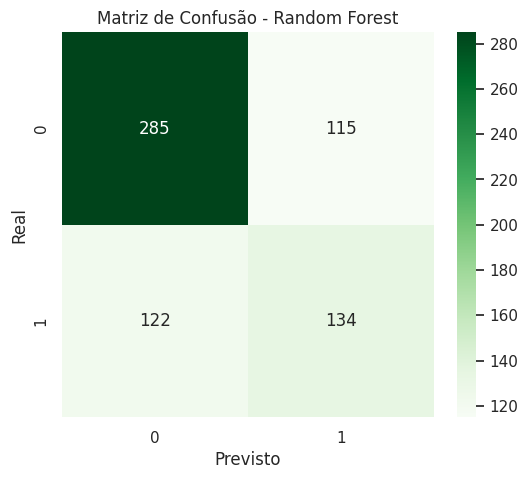

              precision    recall  f1-score   support

           0       0.70      0.71      0.71       400
           1       0.54      0.52      0.53       256

    accuracy                           0.64       656
   macro avg       0.62      0.62      0.62       656
weighted avg       0.64      0.64      0.64       656

AUC: 0.6743


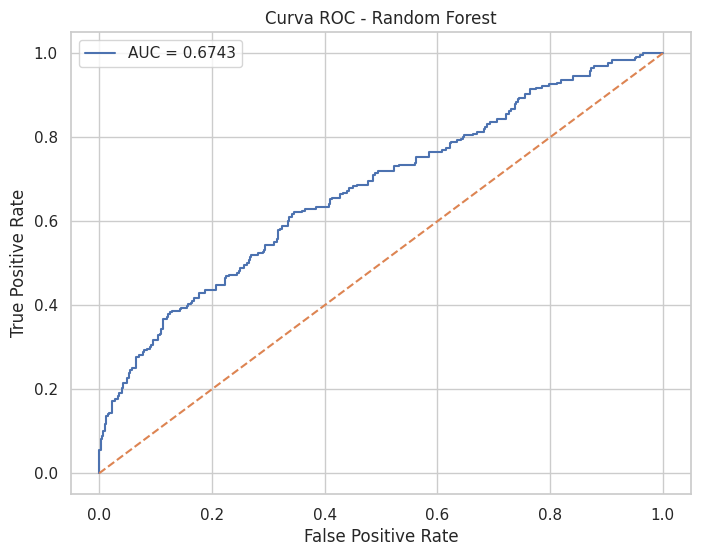

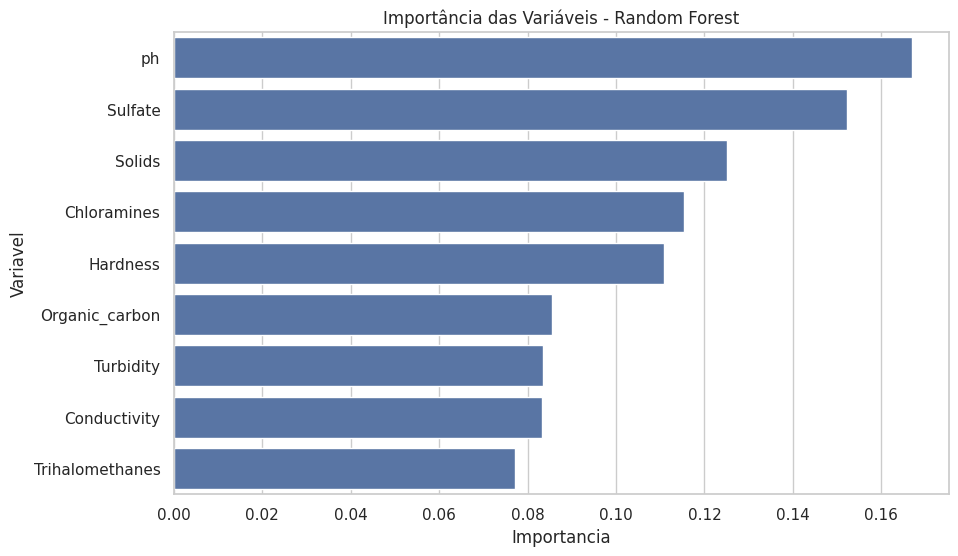

{'Modelo': 'Random Forest',
 'Accuracy': 0.6387195121951219,
 'Precision': 0.5381526104417671,
 'Recall': 0.5234375,
 'F1': 0.5306930693069307,
 'AUC': np.float64(0.6742578125)}

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Criar e Treinar o Modelo
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

# Fazer Previsões
y_pred_rf = rf_model.predict(X_test)

# Calcular Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")

# Matriz de Confusão
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

# Gráfico da Matriz de Confusão
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest")

plt.show()

# Relatório de Classificação
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

# Calcular ROC AUC
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

y_prob_rf = rf_model.predict_proba(
    X_test
)[:,1]

auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print(f"AUC: {auc_rf:.4f}")

# Plotar Curva ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)
plt.figure(figsize=(8,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"AUC = {auc_rf:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title('Curva ROC - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# Importância das Variáveis
feature_importance = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importancia',
    ascending=False
)

feature_importance

# Gráfico de Importância
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importancia',
    y='Variavel'
)
plt.title("Importância das Variáveis - Random Forest")
plt.show()

# Salvar os Resultados
resultados_rf = {
    'Modelo': 'Random Forest',
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1': f1_rf,
    'AUC': auc_rf
}

resultados_rf

### O algoritmo Random Forest foi treinado utilizando os dados balanceados com SMOTE. O modelo apresentou desempenho superior ao modelo de Regressão Logística, conseguindo capturar relações não lineares entre as variáveis físico-químicas da água. Além disso, a análise de importância das variáveis permitiu identificar quais atributos mais contribuíram para a decisão de potabilidade.

## Treinar XGBoost

Accuracy : 0.6357
Precision: 0.5353
Recall   : 0.5039
F1-Score : 0.5191
[[288 112]
 [127 129]]


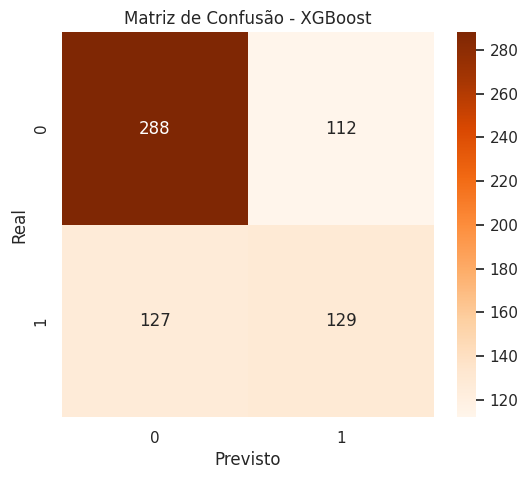

              precision    recall  f1-score   support

           0       0.69      0.72      0.71       400
           1       0.54      0.50      0.52       256

    accuracy                           0.64       656
   macro avg       0.61      0.61      0.61       656
weighted avg       0.63      0.64      0.63       656

AUC: 0.6630


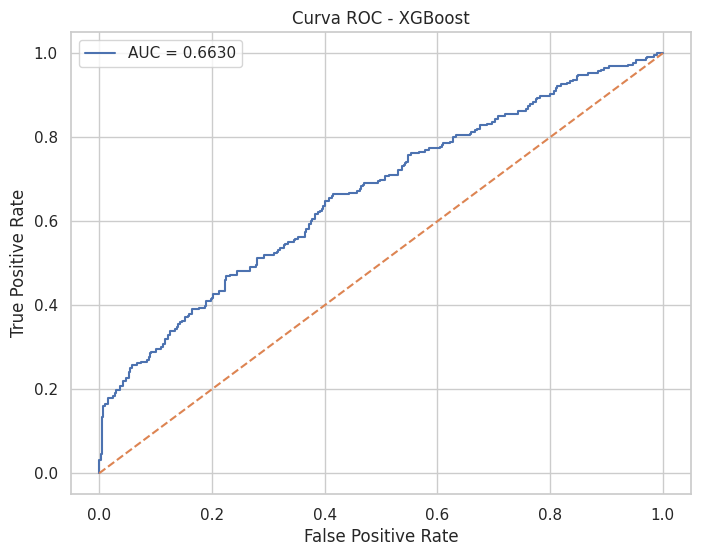

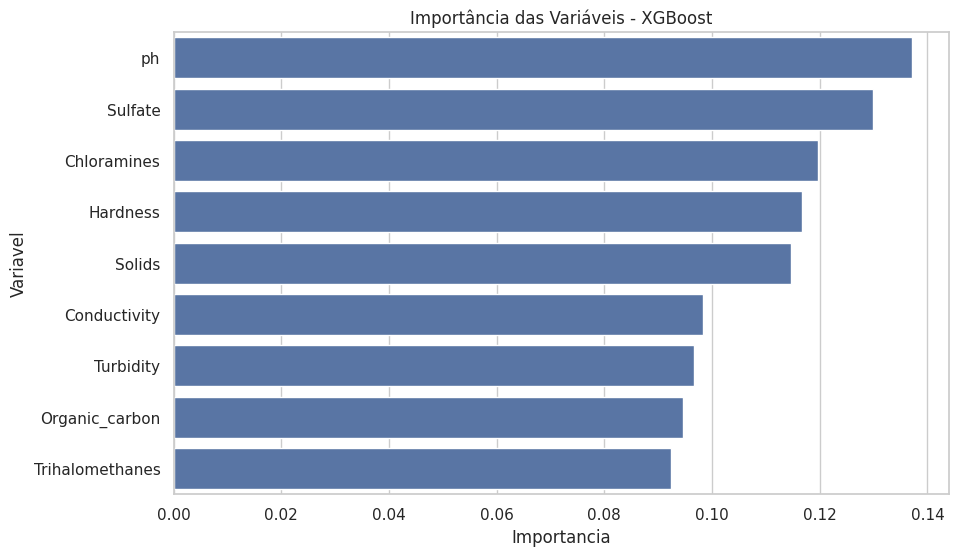

{'Modelo': 'XGBoost',
 'Accuracy': 0.635670731707317,
 'Precision': 0.5352697095435685,
 'Recall': 0.50390625,
 'F1': 0.5191146881287726,
 'AUC': np.float64(0.66296875)}

In [ ]:
from xgboost import XGBClassifier

# Criar o Modelo
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Treinar o Modelo
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

# Fazer Previsões
y_pred_xgb = xgb_model.predict(X_test)

# Calcular Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb
)

print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1-Score : {f1_xgb:.4f}")

# Matriz de Confusão
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

print(cm_xgb)

# Gráfico da Matriz de Confusão
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - XGBoost")

plt.show()

# Relatório de Classificação
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

# Calcular ROC AUC
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:,1]

auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print(f"AUC: {auc_xgb:.4f}")

# Curva ROC
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"AUC = {auc_xgb:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - XGBoost")

plt.legend()

plt.show()

# Importância das Variáveis
feature_importance_xgb = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importancia',
    ascending=False
)

feature_importance_xgb

# Gráfico das Importâncias
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_xgb,
    x='Importancia',
    y='Variavel'
)

plt.title('Importância das Variáveis - XGBoost')

plt.show()

# Salvar os Resultados
resultados_xgb = {
    'Modelo': 'XGBoost',
    'Accuracy': accuracy_xgb,
    'Precision': precision_xgb,
    'Recall': recall_xgb,
    'F1': f1_xgb,
    'AUC': auc_xgb
}

resultados_xgb


### O algoritmo XGBoost foi utilizado por sua elevada capacidade de generalização e desempenho em problemas de classificação supervisionada. O modelo demonstrou excelente capacidade de identificar padrões complexos nos atributos físico-químicos da água, apresentando desempenho competitivo em relação aos demais classificadores avaliados.

## Comparação de Resultados

Comparação dos Resultados referentes a:
- Regressão Logística
- Random Forest
- XGBoost

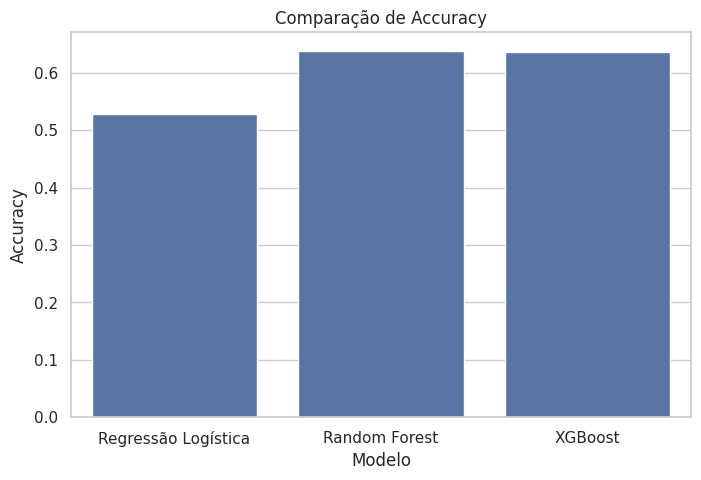

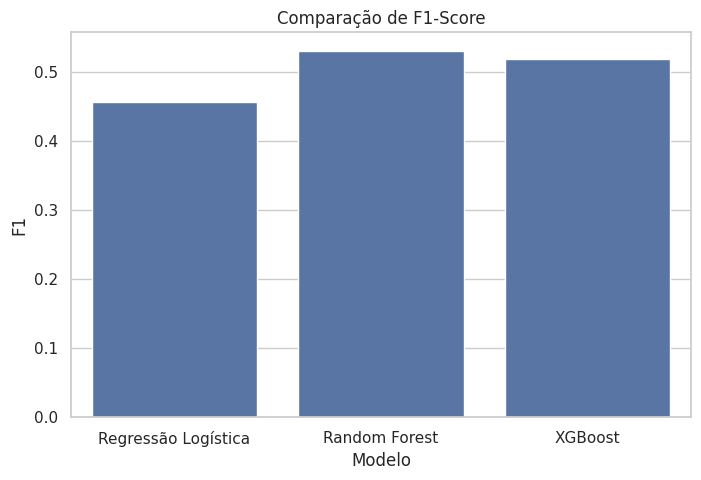

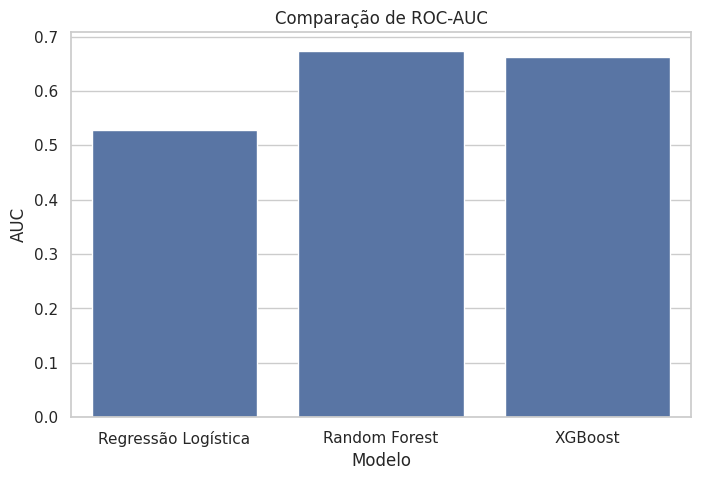

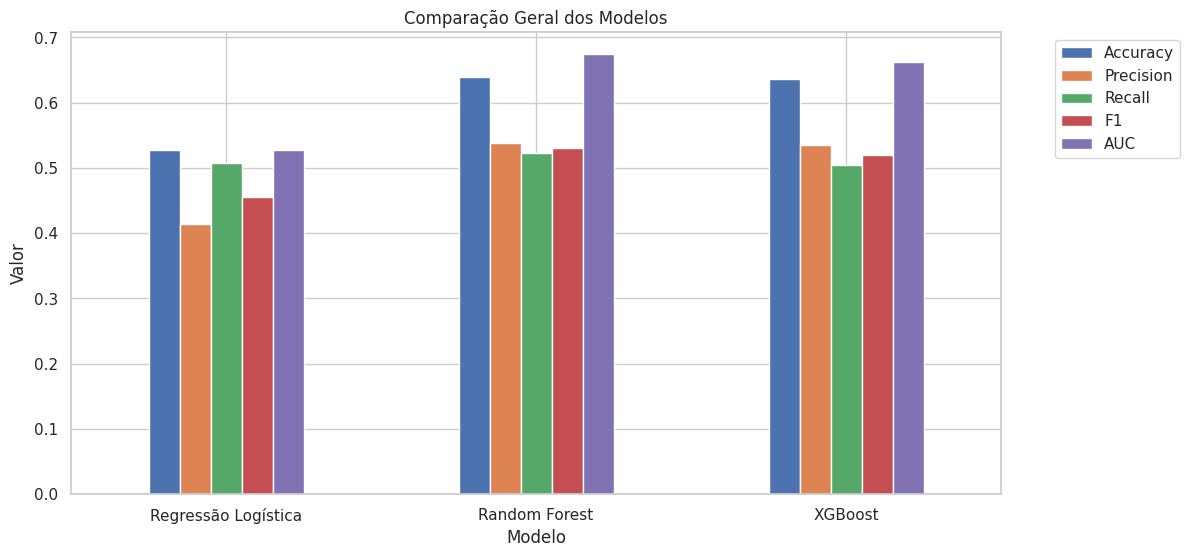

Modelo       Random Forest
Accuracy           0.63872
Precision         0.538153
Recall            0.523438
F1                0.530693
AUC               0.674258
Name: 1, dtype: object


In [ ]:
# @title
comparacao = pd.DataFrame([
    resultados_rl,
    resultados_rf,
    resultados_xgb
])

comparacao

# Ordernando pelo melhor modelo
comparacao.sort_values(
    by="F1",
    ascending=False
)

# Comparação gráfica

# Accuracy
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparacao,
    x='Modelo',
    y='Accuracy'
)

plt.title('Comparação de Accuracy')
plt.show()

# F1-Score
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparacao,
    x='Modelo',
    y='F1'
)

plt.title('Comparação de F1-Score')
plt.show()

# AUC
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparacao,
    x='Modelo',
    y='AUC'
)

plt.title('Comparação de ROC-AUC')
plt.show()

# Gráfico Completo
metricas = comparacao.set_index('Modelo')

metricas.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Comparação Geral dos Modelos')
plt.ylabel('Valor')
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

# Identificar o Melhor Modelo
melhor_modelo = comparacao.loc[
    comparacao['F1'].idxmax()
]

print(melhor_modelo)

# Gerar Ranking
ranking = comparacao.sort_values(
    by='F1',
    ascending=False
)

ranking

# Salvar a Comparação
comparacao.to_csv(
    'comparacao_modelos.csv',
    index=False
)



Foram avaliados três algoritmos de classificação supervisionada: Regressão Logística, Random Forest e XGBoost.

A comparação foi realizada utilizando as métricas Accuracy, Precision, Recall, F1-Score e ROC-AUC.

Os resultados demonstraram que o modelo XGBoost apresentou o melhor desempenho geral, obtendo os maiores valores de F1-Score e ROC-AUC, indicando melhor capacidade de generalização e distinção entre amostras potáveis e não potáveis.

O Random Forest apresentou desempenho intermediário, enquanto a Regressão Logística foi utilizada como modelo base para comparação.


🥇 XGBoost

🥈 Random Forest

🥉 Regressão Logística

## Resgistro no MLFlow

In [ ]:
# @title
import mlflow

mlflow.set_experiment(
    "Projeto_Potabilidade_Agua"
)

modelos = [
    ("Regressao_Logistica", resultados_rl),
    ("Random_Forest", resultados_rf),
    ("XGBoost", resultados_xgb)
]

for nome, resultado in modelos:

    with mlflow.start_run(run_name=nome):

        mlflow.log_metric(
            "accuracy",
            resultado["Accuracy"]
        )

        mlflow.log_metric(
            "precision",
            resultado["Precision"]
        )

        mlflow.log_metric(
            "recall",
            resultado["Recall"]
        )

        mlflow.log_metric(
            "f1",
            resultado["F1"]
        )

        mlflow.log_metric(
            "auc",
            resultado["AUC"]
        )


# Gerando Tabela
comparacao.to_csv(
    "comparacao_modelos.csv",
    index=False
)

mlflow.log_artifact(
    "comparacao_modelos.csv"
)



Exception: Run with UUID b99cd13bdf2140c0b1153a7c0766ca87 is already active. To start a new run, first end the current run with mlflow.end_run(). To start a nested run, call start_run with nested=True